# 04 — Preprocessing and Modelling

**Dataset:** Global Coral Bleaching Database 1980–2020 (van Woesik & Kratochwill 2022)
**Target variable:** `Bleaching_Category`

---

## Contents

1. Preprocessing
   - 1.1 Define feature types
   - 1.2 Exploratory check on categorical columns and encoding strategy
   - 1.3 Temporal train/validation/test split
   - 1.4 Preprocessing pipeline
2. Modelling — 4-class baseline (none / mild / moderate / severe)
   - 2.1 Logistic Regression
   - 2.2 Random Forest
   - 2.3 XGBoost
   - 2.4 Baseline model comparison
3. Addressing class imbalance
4. TimeSeriesSplit cross-validation (abandoned)
5. Binary classification + SMOTE (none / bleaching)
   - 5.1 Random Forest vs XGBoost comparison
6. Error analysis
   - 6.1 False negative analysis
   - 6.1.1 False positive analysis
   - 6.2 Feature ablation: removing Date_Year
   - 6.2.1 Date_Year ablation results

---

## Key methodological decisions

- **Temporal split:** train on 1980–2009, validate on 2010–2014, evaluate on 2015–2019.
  The three major bleaching events (1998, 2005, 2016) are distributed across the three sets.
- **Class imbalance:** handled via `class_weight='balanced'` in baseline models (§2).
  In the binary classification model (§5), SMOTE is used instead — combining both
  mechanisms is redundant as they address the same problem.
- **`Date_Year` as feature:** retained as a conscious choice. The temporal trend 
  (more bleaching in recent years) is ecologically real and directly supported by 
  thermal variables in the dataset. Ablation in §6.2 confirms no measurable 
  temporal overfitting.
- **Primary metric:** recall — missing a bleaching event carries higher ecological cost
  than a false alarm.
- **Secondary metric:** F1-score.
- **Encoding:** one-hot encoding for all categorical features (max 8 unique values per column).
- **Scaling:** StandardScaler for all numerical features, fitted on train only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import TimeSeriesSplit
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

# Setting pandas to show all columns: the dataset has 27 columns and pandas truncates by default
pd.set_option('display.max_columns', None)

In [2]:
# Project colour palette: ocean themed 🌊
color_primary = 'teal'
color_secondary = 'coral'  
color_accent = 'turquoise'

In [3]:
# Importing the data post-feature selection
df = pd.read_csv('../data/processed/bleaching_feature_selection.csv', low_memory=False)
print(df.shape)
df.head()

(32711, 27)


,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Realm_Name,Distance_to_Shore,Exposure,Turbidity,Cyclone_Frequency,Date_Month,Date_Year,Depth_m,Substrate_Name,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Maximum,Windspeed,SSTA,SSTA_DHW,TSA,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_DHW,TSA_DHWMax,TSA_DHWMean,Bleaching_Category
0,23.163,-82.5260,Atlantic,Tropical Atlantic,8519.23,Exposed,0.0287,49.90,9,2005,10.00,Not_Recorded,301.61,302.05,300.67,304.69,8.0,-0.46,0.00,-0.80,1.83,-2.17,0.00,0.00,7.25,0.18,moderate
1,-17.575,-149.7833,Pacific,Eastern Indo-Pacific,1431.62,Exposed,0.0262,51.20,3,1991,14.00,Not_Recorded,262.15,303.30,300.73,305.01,2.0,1.29,0.26,1.29,3.00,-1.26,0.25,0.26,4.65,0.19,moderate
2,18.369,-64.5640,Atlantic,Tropical Atlantic,182.33,Exposed,0.0429,61.52,1,2006,7.00,Not_Recorded,298.79,299.18,300.32,304.14,8.0,0.04,0.00,-2.64,2.31,-1.49,7.00,0.00,11.66,0.26,moderate
3,17.760,-64.5680,Atlantic,Tropical Atlantic,313.13,Exposed,0.0424,65.39,4,2006,9.02,Not_Recorded,300.16,299.61,300.38,304.07,3.0,-0.07,0.00,-2.27,2.19,-1.49,3.00,0.00,5.64,0.20,moderate
4,17.769,-64.5830,Atlantic,Tropical Atlantic,792.00,Exposed,0.0424,65.39,4,2006,12.50,Not_Recorded,300.15,299.70,300.38,303.76,3.0,0.00,0.00,-2.19,1.87,-1.50,3.00,0.00,6.89,0.25,moderate


In [4]:
# Sanity check: no missing values expected after feature selection
df.isna().sum()

Latitude_Degrees       0
Longitude_Degrees      0
Ocean_Name             0
Realm_Name             0
Distance_to_Shore      0
Exposure               0
Turbidity              0
Cyclone_Frequency      0
Date_Month             0
Date_Year              0
Depth_m                0
Substrate_Name         0
ClimSST                0
Temperature_Kelvin     0
Temperature_Mean       0
Temperature_Maximum    0
Windspeed              0
SSTA                   0
SSTA_DHW               0
TSA                    0
TSA_Maximum            0
TSA_Mean               0
TSA_Frequency          0
TSA_DHW                0
TSA_DHWMax             0
TSA_DHWMean            0
Bleaching_Category     0
dtype: int64

## 1. Preprocessing

### 1.1 Define feature types

We separate the 26 features into two groups:
- **Numerical**: continuous variables that need scaling
- **Categorical**: string variables that need encoding

This separation is needed to apply different preprocessing steps to each group.

In [5]:
num_cols = [
    'Latitude_Degrees', 'Longitude_Degrees', 'Distance_to_Shore',
    'Turbidity', 'Cyclone_Frequency', 'Date_Month', 'Date_Year',
    'Depth_m', 'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean',
    'Temperature_Maximum', 'Windspeed', 'SSTA', 'SSTA_DHW',
    'TSA', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency',
    'TSA_DHW', 'TSA_DHWMax', 'TSA_DHWMean']

cat_cols = ['Ocean_Name', 'Realm_Name', 'Substrate_Name', 'Exposure']

target = 'Bleaching_Category'

### 1.2 Exploratory check on categorical string columns

Before building the preprocessing pipeline, we inspect the categorical string columns
to understand how many unique values each one contains. This informs our encoding choices.

In [6]:
# Inspection of categorical columns
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Ocean_Name ---
Ocean_Name
Pacific         16264
Atlantic        13087
Indian           1982
Red Sea          1037
Arabian Gulf      341
Name: count, dtype: int64

--- Realm_Name ---
Realm_Name
Central Indo-Pacific           13793
Tropical Atlantic              13076
Western Indo-Pacific            3140
Eastern Indo-Pacific            1618
Temperate Australasia            532
Temperate Northern Pacific       491
Tropical Eastern Pacific          50
Temperate Northern Atlantic       11
Name: count, dtype: int64

--- Substrate_Name ---
Substrate_Name
Hard Coral                  11178
Nutrient Indicator Algae    10960
Not_Recorded                10355
Fleshy Seaweed                218
Name: count, dtype: int64

--- Exposure ---
Exposure
Sheltered    18240
Exposed      11794
Sometimes     2677
Name: count, dtype: int64


### Encoding strategy for categorical columns

All four categorical columns have low cardinality (between 3 and 8 unique values).
One-hot encoding is a viable strategy for all of them. Using `drop='first'` to avoid 
multicollinearity, it will add 16 new columns in total (4 + 7 + 3 + 2), keeping the 
feature space manageable.

### 1.3 Train/Validation/Test split

In [7]:
# Checking the number of observation per year before deciding on the best test/validation/train strategy
print(df.groupby('Date_Year').size())

Date_Year
1983       4
1987      16
1988       1
1990       1
1991       4
1992       5
1993       6
1994      11
1995       6
1996      10
1997       9
1998     177
1999     721
2000     549
2001     703
2002     565
2003    1644
2004    1677
2005    3886
2006    2775
2007    1519
2008    1901
2009    1931
2010    1549
2011    1356
2012    1400
2013    1517
2014    1409
2015    1558
2016    1803
2017    1581
2018    1243
2019    1174
dtype: int64


In [8]:
# Inspecting the number of observations for the proposed train/val/test split
periods = {
    '1980-2009': (1980, 2009),
    '2010-2014': (2010, 2014),
    '2015-2019': (2015, 2019)
}

for name, (start, end) in periods.items():
    count = df[(df['Date_Year'] >= start) & (df['Date_Year'] <= end)].shape[0]
    print(f"{name}: {count} observations")

1980-2009: 18121 observations
2010-2014: 7231 observations
2015-2019: 7359 observations


### Temporal Train/Validation/Test split

We split the dataset into three periods based on year:

- **Train:      1980–2009  →  18,121 observations**
- **Validation: 2010–2014  →   7,231 observations**
- **Test:       2015–2019  →   7,359 observations**

This split is chosen because it respects the temporal structure of the data
and ensures that the three major documented bleaching events are distributed meaningfully:
the 1998 and 2005 events fall in the training set, the 2010 event in validation,
and the 2016 event in the test set, which the model will only see at final evaluation.

The scarce pre-1997 data is not a concern: systematic coral bleaching monitoring
only became widespread after the 1997–1998 El Niño event, so the low observation
count before that date reflects the historical record, not a data quality issue.

In [9]:
# Splitting the dataset into training, validation and testing subsets
train = df[df['Date_Year'] <= 2009]
validation = df[(df['Date_Year'] >= 2010) & (df['Date_Year'] <= 2014)]
test = df[df['Date_Year'] >= 2015]

X_train = train.drop(columns='Bleaching_Category')
y_train = train['Bleaching_Category']

X_val = validation.drop(columns='Bleaching_Category')
y_val = validation['Bleaching_Category']

X_test = test.drop(columns='Bleaching_Category')
y_test = test['Bleaching_Category']

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")

Train:      (18121, 26)
Validation: (7231, 26)
Test:       (7359, 26)


### 1.4 Preprocessing pipeline

We build a preprocessing pipeline using `ColumnTransformer` from sklearn.
This applies two transformations in parallel:
- `StandardScaler` on numerical columns
- `OneHotEncoder` on categorical columns

The pipeline is fitted on the training set only, then applied to validation and test.
This prevents data leakage from future observations into the training process.

In [10]:
# Preprocessing pipeline: StandardScaler for numerical columns, OneHotEncoder for categorical columns
# The pipeline is fitted on the training set only to prevent data leakage
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

In [11]:
# Fit on train only, then transform all three sets
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Train processed:      {X_train_processed.shape}")
print(f"Validation processed: {X_val_processed.shape}")
print(f"Test processed:       {X_test_processed.shape}")

Train processed:      (18121, 38)
Validation processed: (7231, 38)
Test processed:       (7359, 38)


### A note on fit_transform() Vs transform()

- `fit_transform(X_train)`: learns the statistics from the training set (e.g. mean and 
  standard deviation for scaling, unique categories for encoding) and applies the 
  transformation. This is called only once, on the training set.

- `transform(X_val)` and `transform(X_test)`: applies the same transformation learned 
  from the training set, without relearning anything. This ensures that validation and 
  test are scaled and encoded using training statistics only, preventing data leakage.

## 2. Modelling

### 2.1 Logistic Regression baseline model

Logistic Regression is our simplest model and serves as a baseline.
We use `class_weight='balanced'` to handle class imbalance, and evaluate
on the validation set using recall as primary metric and F1 as secondary.

Logistic Regression has regularisation built in by default (C=1.0), 
so no additional constraints are needed for the baseline.

In [12]:
# Train the model
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_processed, y_train)

# Predict on validation set
y_pred_lr = lr.predict(X_val_processed)

# Evaluation
print(classification_report(y_val, y_pred_lr))

              precision    recall  f1-score   support

        mild       0.19      0.59      0.29       533
    moderate       0.15      0.25      0.19       255
        none       0.96      0.73      0.83      6327
      severe       0.12      0.34      0.18       116

    accuracy                           0.70      7231
   macro avg       0.36      0.48      0.37      7231
weighted avg       0.86      0.70      0.76      7231



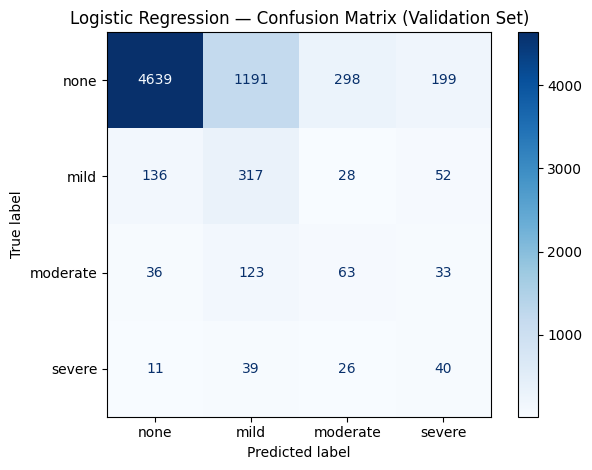

In [13]:
cm = confusion_matrix(y_val, y_pred_lr, labels=['none', 'mild', 'moderate', 'severe'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['none', 'mild', 'moderate', 'severe'])

disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

### 2.1.1 Logistic Regression — Results

**Classification report highlights:**
- `none` is the only well-performing class: recall 0.73, F1 0.83.
- `severe` recall is 0.34. The model misses 2 out of 3 severe bleaching events.
  This is the most ecologically costly error in this project.
- `moderate` recall is 0.25. More than half of moderate bleaching cases are 
  misclassified as mild or none.
- Overall accuracy of 70% is misleading: it is inflated by the dominance of the 
  `none` class (6,327 out of 7,231 validation observations).
- **Macro F1: 0.37**. This is the honest summary metric, as it treats all classes equally.

**Confusion matrix highlights:**
- Of 116 severe cases, only 40 are correctly identified. 39 are predicted as mild, 
  26 as moderate: the model systematically underestimates bleaching severity.
- Of 255 moderate cases, only 63 are correctly identified.

**Conclusion:** Logistic Regression captures the dominant class well but fails on minority 
classes. This is expected

### 2.2 Random Forest baseline model

Random Forest builds an ensemble of decision trees, each trained on a random subset 
of the data and features. It captures non-linear relationships that Logistic Regression 
cannot.

To avoid pathological overfitting from fully grown trees, we set `max_depth=10` and 
`min_samples_leaf=5` as minimum constraints. `class_weight='balanced'` handles class imbalance.

In [14]:
# Train the model
rf = RandomForestClassifier(
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)
rf.fit(X_train_processed, y_train)

# Predict on validation set
y_pred_rf = rf.predict(X_val_processed)

# Evaluation
print(classification_report(y_val, y_pred_rf))

              precision    recall  f1-score   support

        mild       0.28      0.55      0.37       533
    moderate       0.27      0.17      0.21       255
        none       0.94      0.89      0.92      6327
      severe       0.30      0.15      0.20       116

    accuracy                           0.83      7231
   macro avg       0.45      0.44      0.42      7231
weighted avg       0.86      0.83      0.84      7231



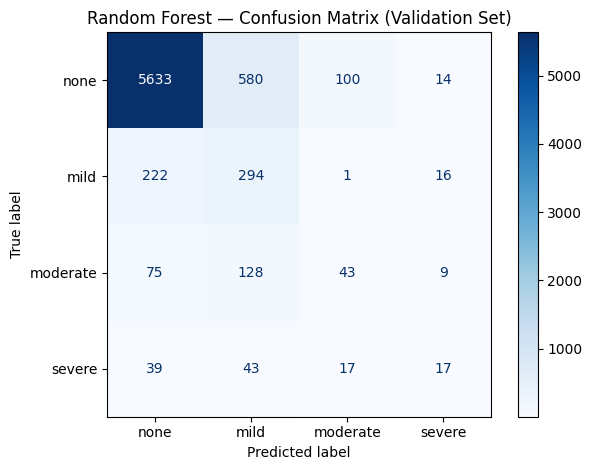

In [15]:
cm = confusion_matrix(y_val, y_pred_rf, labels=['none', 'mild', 'moderate', 'severe'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['none', 'mild', 'moderate', 'severe'])

disp.plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

### 2.2.1 Random Forest — Results

**Classification report highlights:**
- Macro F1 improves from 0.37 (Logistic Regression) to 0.42 — a real but modest gain.
- `none` improves significantly: recall 0.73 → 0.89.
- `mild` improves slightly: F1 0.29 → 0.37. The model correctly identifies 294/533 
  mild cases, but 222 are misclassified as none.
- `moderate` worsens: recall 0.25 → 0.17. 75 moderate cases are predicted as none.
- `severe` worsens significantly: recall 0.34 → 0.15. Only 17 out of 116 severe 
  bleaching events are correctly identified. 39 are predicted as none.

**Confusion matrix highlights:**
- The model becomes more conservative on minority classes compared to Logistic Regression,
  trading recall on severe and moderate for better performance on none.
- `class_weight='balanced'` is insufficient to compensate for the extreme imbalance 
  (6,327 none out of 7,231 validation observations).

**Conclusion:** Random Forest captures the dominant class well but systematically 
underestimates bleaching severity. The core problem is the class imbalance.
If XGBoost shows the same pattern, more aggressive rebalancing strategies 
will be needed during tuning (e.g. SMOTE, adjusted class weights, threshold tuning).

### 2.3 XGBoost baseline model

XGBoost builds trees sequentially, where each tree corrects the errors of the previous one.
It has regularisation built in by default, so vanilla parameters are already reasonable.
Class imbalance is handled by passing sample weights computed from the training labels,
since XGBoost multiclass does not support `class_weight='balanced'` natively.

In [16]:
# Compute sample weights to handle class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Encode target labels as integers (XGBoost requires numeric labels)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

# Train the model
xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train_processed, y_train_enc, sample_weight=sample_weights)

# Predict on validation set
y_pred_xgb_enc = xgb_model.predict(X_val_processed)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

# Evaluation
print(classification_report(y_val, y_pred_xgb))

              precision    recall  f1-score   support

        mild       0.29      0.47      0.36       533
    moderate       0.14      0.04      0.06       255
        none       0.93      0.92      0.92      6327
      severe       0.32      0.09      0.15       116

    accuracy                           0.84      7231
   macro avg       0.42      0.38      0.37      7231
weighted avg       0.84      0.84      0.84      7231



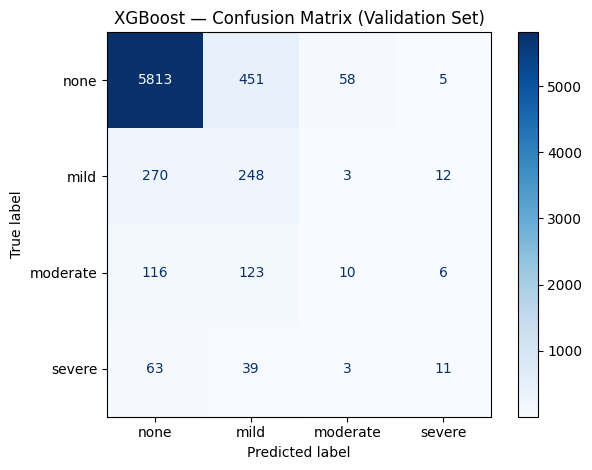

In [17]:
cm = confusion_matrix(y_val, y_pred_xgb, labels=['none', 'mild', 'moderate', 'severe'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['none', 'mild', 'moderate', 'severe'])

disp.plot(cmap='Blues')
plt.title('XGBoost — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

### 2.3.1 XGBoost — Results

**Classification report highlights:**
- Macro F1: 0.37 — identical to Logistic Regression, worse than Random Forest (0.42).
- `none`: recall 0.92, F1 0.92 — the best performance on this class across all three models.
- `mild`: recall 0.47, F1 0.36 — only 248/533 correctly identified, 270 predicted as none.
- `moderate`: recall 0.04, F1 0.06 — the worst performance across all three models. 
  116 out of 255 moderate cases predicted as none.
- `severe`: recall 0.09, F1 0.15 — only 11/116 severe bleaching events correctly identified.
  63 predicted as none.

**Confusion matrix highlights:**
- XGBoost is the most conservative model on minority classes: it predicts none 
  more aggressively than both Logistic Regression and Random Forest.
- Sample weights via `compute_sample_weight` are insufficient to compensate 
  for the extreme class imbalance.

**Conclusion:** XGBoost vanilla performs worst on the ecologically critical classes 
(severe and moderate). It will require the most aggressive tuning to become useful.

## 3. Baseline Model Comparison and Class Imbalance

All three baseline models show the same failure pattern: they predict `none` 
aggressively and systematically underestimate bleaching severity.
This is not a model quality problem, it is a class imbalance problem.

**Class distribution in the validation set:**
- none: 6,327 (87.5%)
- mild: 533 (7.4%)
- moderate: 255 (3.5%)
- severe: 116 (1.6%)

| Model               | Accuracy | Macro F1 | Recall (none) | Recall (mild) | Recall (moderate) | Recall (severe) |
|---------------------|----------|----------|---------------|---------------|-------------------|-----------------|
| Logistic Regression | 0.70     | 0.37     | 0.73          | 0.59          | 0.25              | 0.34            |
| Random Forest       | 0.83     | 0.42     | 0.89          | 0.55          | 0.17              | 0.15            |
| XGBoost             | 0.84     | 0.37     | 0.92          | 0.47          | 0.04              | 0.09            |

`class_weight='balanced'` and sample weights are insufficient when the imbalance 
is this extreme. More aggressive strategies are needed.

**Options considered:**
1. Reduce to 3 classes: merge `moderate` and `severe` into `high`.
2. Reduce to binary: `none` vs `bleaching`.
3. Keep 4 classes with aggressive tuning: SMOTE, threshold tuning, adjusted weights.

**Decision:** reduce to binary classification and apply SMOTE. If performance 
remains insufficient, regional models per ecoregion will be explored as future work.

## 4. TimeSeriesSplit Cross-Validation

The fixed validation period (2010–2014) is a relatively quiet period with limited 
bleaching events, making it unrepresentative for model evaluation. We switch to 
TimeSeriesSplit cross-validation on the full pre-2015 data, which evaluates the model 
across multiple time windows including the 1998 and 2005 major bleaching events.

The test set (2015–2019) remains untouched and will only be used for final evaluation.

In [18]:
# Full pre-2015 data for cross-validation
train_ts = df[df['Date_Year'] < 2015]
test_ts = df[df['Date_Year'] >= 2015]

X_train_ts = train_ts.drop(columns='Bleaching_Category')
y_train_ts = train_ts['Bleaching_Category']

X_test_ts = test_ts.drop(columns='Bleaching_Category')
y_test_ts = test_ts['Bleaching_Category']

print(f"Train: {X_train_ts.shape}")
print(f"Test:  {X_test_ts.shape}")

Train: (25352, 26)
Test:  (7359, 26)


In [19]:
# Separate preprocessor for TimeSeriesSplit
# It avoids overwriting the fit from earlier sections if cells are re-executed out of order
preprocessor_ts = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

X_train_ts_processed = preprocessor_ts.fit_transform(X_train_ts)
X_test_ts_processed = preprocessor_ts.transform(X_test_ts)

print(f"Train processed: {X_train_ts_processed.shape}")
print(f"Test processed:  {X_test_ts_processed.shape}")

Train processed: (25352, 38)
Test processed:  (7359, 38)


In [20]:
# TimeSeriesSplit cross-validation on Random Forest
tscv = TimeSeriesSplit(n_splits=5)

rf_ts = RandomForestClassifier(
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)

scores = cross_val_score(
    rf_ts, 
    X_train_ts_processed, 
    y_train_ts, 
    cv=tscv, 
    scoring='f1_macro'
)

print(f"F1 macro per fold: {scores.round(3)}")
print(f"Mean F1 macro:     {scores.mean().round(3)}")
print(f"Std:               {scores.std().round(3)}")

F1 macro per fold: [0.206 0.25  0.236 0.246 0.231]
Mean F1 macro:     0.234
Std:               0.015


## 5. Binary Classification with SMOTE

TimeSeriesSplit cross-validation produced worse results than the fixed validation 
split (mean macro F1: 0.234 vs 0.42), likely due to the sparse bleaching data in 
early time windows. We abandon this approach.

Given the extreme class imbalance and the failure of all three baseline models to 
detect minority classes reliably, we adopt two strategies in combination:

1. **Binary target:** `none` vs `bleaching` (merging mild, moderate, severe)
2. **SMOTE** (Synthetic Minority Oversampling Technique): generates synthetic 
   observations of the minority class in the training set to balance the distribution

The test set remains untouched: SMOTE is applied only to the training data.

In [21]:
# Remap target to binary
df['Bleaching_Binary'] = df['Bleaching_Category'].apply(
    lambda x: 'none' if x == 'none' else 'bleaching'
)
print(df['Bleaching_Binary'].value_counts())

Bleaching_Binary
none         26929
bleaching     5782
Name: count, dtype: int64


In [22]:
# Train/Validation/Test split
train_bin = df[df['Date_Year'] <= 2009]
validation_bin = df[(df['Date_Year'] >= 2010) & (df['Date_Year'] <= 2014)]
test_bin = df[df['Date_Year'] >= 2015]

X_train_bin = train_bin.drop(columns=['Bleaching_Category', 'Bleaching_Binary'])
y_train_bin = train_bin['Bleaching_Binary']

X_val_bin = validation_bin.drop(columns=['Bleaching_Category', 'Bleaching_Binary'])
y_val_bin = validation_bin['Bleaching_Binary']

X_test_bin = test_bin.drop(columns=['Bleaching_Category', 'Bleaching_Binary'])
y_test_bin = test_bin['Bleaching_Binary']

print(f"Train:      {X_train_bin.shape}")
print(f"Validation: {X_val_bin.shape}")
print(f"Test:       {X_test_bin.shape}")

Train:      (18121, 26)
Validation: (7231, 26)
Test:       (7359, 26)


In [23]:
# Separate preprocessor for binary classification.
# It avoids overwriting the fit from earlier sections if cells are re-executed out of order
preprocessor_bin = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

X_train_bin_processed = preprocessor_bin.fit_transform(X_train_bin)
X_val_bin_processed = preprocessor_bin.transform(X_val_bin)
X_test_bin_processed = preprocessor_bin.transform(X_test_bin)

print(f"Train processed:      {X_train_bin_processed.shape}")
print(f"Validation processed: {X_val_bin_processed.shape}")
print(f"Test processed:       {X_test_bin_processed.shape}")

Train processed:      (18121, 38)
Validation processed: (7231, 38)
Test processed:       (7359, 38)


In [24]:
# Check class distribution before SMOTE
print("Before SMOTE:")
print(y_train_bin.value_counts())

Before SMOTE:
Bleaching_Binary
none         14359
bleaching     3762
Name: count, dtype: int64


In [25]:
# SMOTE generates synthetic observations of the minority class (bleaching) until both classes are balanced.
# Applied only to the training set.
# Validation and test remain untouched to reflect real-world class distribution.
smote = SMOTE(random_state=42)
X_train_bin_smote, y_train_bin_smote = smote.fit_resample(X_train_bin_processed, y_train_bin)

print("After SMOTE:")
print(y_train_bin_smote.value_counts())
print(f"\nShape: {X_train_bin_smote.shape}")

After SMOTE:
Bleaching_Binary
bleaching    14359
none         14359
Name: count, dtype: int64

Shape: (28718, 38)


In [26]:
# Applying Random Forest to the balanced dataset.
rf_bin = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)
rf_bin.fit(X_train_bin_smote, y_train_bin_smote)

y_pred_rf_bin = rf_bin.predict(X_val_bin_processed)

print(classification_report(y_val_bin, y_pred_rf_bin))

              precision    recall  f1-score   support

   bleaching       0.47      0.61      0.53       904
        none       0.94      0.90      0.92      6327

    accuracy                           0.86      7231
   macro avg       0.71      0.76      0.73      7231
weighted avg       0.88      0.86      0.87      7231



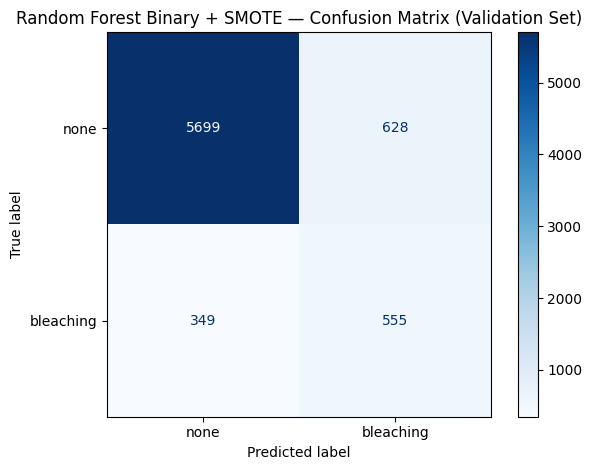

In [27]:
cm = confusion_matrix(y_val_bin, y_pred_rf_bin, labels=['none', 'bleaching'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['none', 'bleaching'])

disp.plot(cmap='Blues')
plt.title('Random Forest Binary + SMOTE — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

In [28]:
# Separate LabelEncoder for binary XGBoost.
# It  avoids overwriting le from 2.3.
le_bin = LabelEncoder()
y_train_bin_smote_enc = le_bin.fit_transform(y_train_bin_smote)
y_val_bin_enc = le_bin.transform(y_val_bin)

xgb_bin = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_bin.fit(X_train_bin_smote, y_train_bin_smote_enc)

y_pred_xgb_bin_enc = xgb_bin.predict(X_val_bin_processed)
y_pred_xgb_bin = le_bin.inverse_transform(y_pred_xgb_bin_enc)

print(classification_report(y_val_bin, y_pred_xgb_bin))

              precision    recall  f1-score   support

   bleaching       0.49      0.41      0.45       904
        none       0.92      0.94      0.93      6327

    accuracy                           0.87      7231
   macro avg       0.70      0.67      0.69      7231
weighted avg       0.86      0.87      0.87      7231



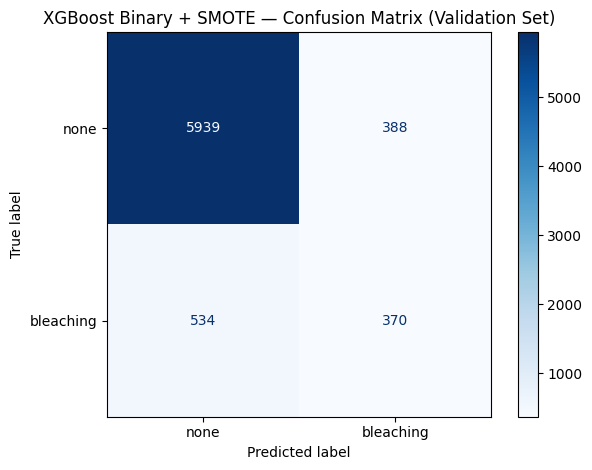

In [29]:
cm = confusion_matrix(y_val_bin, y_pred_xgb_bin, labels=['none', 'bleaching'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['none', 'bleaching'])

disp.plot(cmap='Blues')
plt.title('XGBoost Binary + SMOTE — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

## 5.1 Binary Classification + SMOTE — Model Comparison

| Model         | Accuracy | Macro F1 | Recall (bleaching) | Recall (none) |
|---------------|----------|----------|--------------------|---------------|
| Random Forest | 0.86     | 0.73     | 0.61               | 0.90          |
| XGBoost       | 0.87     | 0.69     | 0.41               | 0.94          |

**Random Forest is the better model for this project.**

- RF recall on `bleaching`: 0.61. Correctly identifies 555 out of 904 bleaching events.
  349 bleaching events are missed (false negatives).
- XGBoost recall on `bleaching`: 0.41. Misses 533 out of 904 bleaching events.
  Higher accuracy but worse on the metric that matters ecologically.
- XGBoost trades bleaching recall for better none recall (0.94 vs 0.90). 
  The wrong trade-off for this problem.

**SMOTE alone is sufficient for RF** — recall 0.61 is identical to the earlier version
that combined SMOTE with `class_weight='balanced'`. The two mechanisms are redundant:
SMOTE already balances the training set, so `class_weight` adds nothing on top.
SMOTE provided a meaningful improvement for XGBoost but performance remains 
below RF on the primary metric.

**Conclusion:** Random Forest Binary + SMOTE is selected as the model to tune.
Target: improve bleaching recall above 0.61 while keeping precision above 0.40.
Next step: GridSearchCV on `max_depth`, `n_estimators`, `min_samples_leaf`.

## 6. Error Analysis

Before tuning, we analyse where the model fails systematically.
Understanding which observations are misclassified (by year, ocean, and realm)
informs tuning decisions and helps identify structural limitations of the global model.

In [30]:
# Add predictions to validation set for error analysis
val_analysis = X_val_bin.copy()
val_analysis['y_true'] = y_val_bin.values
val_analysis['y_pred'] = y_pred_rf_bin

# False negatives: bleaching events predicted as none
false_negatives = val_analysis[
    (val_analysis['y_true'] == 'bleaching') & 
    (val_analysis['y_pred'] == 'none')
]

print(f"Total false negatives: {len(false_negatives)}")
print(f"Total bleaching events: {len(val_analysis[val_analysis['y_true'] == 'bleaching'])}")
print(f"Miss rate: {len(false_negatives) / len(val_analysis[val_analysis['y_true'] == 'bleaching']):.2f}")

Total false negatives: 349
Total bleaching events: 904
Miss rate: 0.39


In [31]:
# False negatives by ocean
print("--- False negatives by Ocean ---")
print(false_negatives['Ocean_Name'].value_counts())

print("\n--- False negatives by Realm ---")
print(false_negatives['Realm_Name'].value_counts())

print("\n--- False negatives by Year ---")
print(false_negatives['Date_Year'].value_counts().sort_index())

--- False negatives by Ocean ---
Ocean_Name
Pacific         236
Atlantic        107
Red Sea           4
Arabian Gulf      2
Name: count, dtype: int64

--- False negatives by Realm ---
Realm_Name
Central Indo-Pacific          204
Tropical Atlantic             107
Temperate Northern Pacific     12
Temperate Australasia          12
Western Indo-Pacific            6
Tropical Eastern Pacific        6
Eastern Indo-Pacific            2
Name: count, dtype: int64

--- False negatives by Year ---
Date_Year
2010    139
2011     40
2012     24
2013     70
2014     76
Name: count, dtype: int64


### 6.1 False Negative Analysis

The model misses 349 out of 904 bleaching events (miss rate: 0.39).

**By Ocean:**
- Pacific: 236 false negatives (67% of all false negatives)
- Atlantic: 107 false negatives (31%)
- Red Sea and Arabian Gulf: 6 combined

**By Realm:**
- Central Indo-Pacific: 204 false negatives (58% of all false negatives):
  disproportionate given it represents ~42% of total observations. 
  The model has a systematic geographic bias against this region.
- Tropical Atlantic: 107 false negatives: all Atlantic errors fall here,
  confirming that Ocean_Name and Realm_Name are partially redundant.

**By Year:**
- 2010 accounts for 139 out of 349 false negatives (40% of all errors in a single year).
  The 2010 event is a moderate post-El Niño bleaching episode: its thermal signature 
  may differ from the major 1998 and 2005 events the model learned from.
- 2011–2014 are relatively homogeneous (24–76 false negatives per year).

**Key findings:**
- The model has a systematic bias against the Central Indo-Pacific region.
- Ocean_Name and Realm_Name contain overlapping information: 
  one of the two may be redundant as a feature.
- The 2010 anomaly warrants further investigation during tuning.

**Structural limitations:**
- The training set (1980–2009) is dominated by Atlantic and Central Indo-Pacific 
  observations. Temperate regions and the Eastern Pacific are severely underrepresented, 
  which explains the near-zero recall in those areas.
- A dataset extending to 2024 or beyond would significantly improve model performance 
  for these regions: the Great Barrier Reef and Indo-Pacific have experienced major 
  bleaching events in 2016, 2017, 2020, 2022, and 2024. Including those observations 
  would give the model the signal it currently lacks for temperate and Pacific realms.
- Regional models are recommended as future work, after the current global model is finalised.

In [32]:
# Compare false negative rate by ocean vs total bleaching events
total_bleaching = val_analysis[val_analysis['y_true'] == 'bleaching']

print("--- False negative rate by Ocean ---")
for ocean in total_bleaching['Ocean_Name'].unique():
    total = len(total_bleaching[total_bleaching['Ocean_Name'] == ocean])
    fn = len(false_negatives[false_negatives['Ocean_Name'] == ocean])
    print(f"{ocean}: {fn}/{total} ({fn/total:.2f})")

print("\n--- False negative rate by Realm ---")
for realm in total_bleaching['Realm_Name'].unique():
    total = len(total_bleaching[total_bleaching['Realm_Name'] == realm])
    fn = len(false_negatives[false_negatives['Realm_Name'] == realm])
    print(f"{realm}: {fn}/{total} ({fn/total:.2f})")

--- False negative rate by Ocean ---
Indian: 0/11 (0.00)
Pacific: 236/319 (0.74)
Arabian Gulf: 2/4 (0.50)
Atlantic: 107/564 (0.19)
Red Sea: 4/6 (0.67)

--- False negative rate by Realm ---
Western Indo-Pacific: 6/19 (0.32)
Central Indo-Pacific: 204/277 (0.74)
Tropical Atlantic: 107/564 (0.19)
Temperate Northern Pacific: 12/19 (0.63)
Eastern Indo-Pacific: 2/6 (0.33)
Tropical Eastern Pacific: 6/7 (0.86)
Temperate Australasia: 12/12 (1.00)


In [33]:
# False positives: none events predicted as bleaching
false_positives = val_analysis[
    (val_analysis['y_true'] == 'none') & 
    (val_analysis['y_pred'] == 'bleaching')
]

print(f"Total false positives: {len(false_positives)}")
print(f"Total none events: {len(val_analysis[val_analysis['y_true'] == 'none'])}")
print(f"False alarm rate: {len(false_positives) / len(val_analysis[val_analysis['y_true'] == 'none']):.2f}")

print("\n--- False positives by Ocean ---")
for ocean in val_analysis['Ocean_Name'].unique():
    total = len(val_analysis[(val_analysis['y_true'] == 'none') & (val_analysis['Ocean_Name'] == ocean)])
    fp = len(false_positives[false_positives['Ocean_Name'] == ocean])
    if total > 0:
        print(f"{ocean}: {fp}/{total} ({fp/total:.2f})")

print("\n--- False positives by Realm ---")
for realm in val_analysis['Realm_Name'].unique():
    total = len(val_analysis[(val_analysis['y_true'] == 'none') & (val_analysis['Realm_Name'] == realm)])
    fp = len(false_positives[false_positives['Realm_Name'] == realm])
    if total > 0:
        print(f"{realm}: {fp}/{total} ({fp/total:.2f})")

Total false positives: 628
Total none events: 6327
False alarm rate: 0.10

--- False positives by Ocean ---
Indian: 1/433 (0.00)
Pacific: 100/3860 (0.03)
Arabian Gulf: 0/166 (0.00)
Atlantic: 527/1535 (0.34)
Red Sea: 0/333 (0.00)

--- False positives by Realm ---
Western Indo-Pacific: 1/936 (0.00)
Central Indo-Pacific: 76/3082 (0.02)
Tropical Atlantic: 527/1535 (0.34)
Temperate Northern Pacific: 5/153 (0.03)
Eastern Indo-Pacific: 17/404 (0.04)
Temperate Australasia: 0/211 (0.00)
Tropical Eastern Pacific: 2/6 (0.33)


### 6.1.1 False Positive Analysis

The model generates 628 false positives out of 6,327 none events (false alarm rate: 0.10).

**By Ocean:**
- Atlantic: 527/1535 (0.34): by far the highest false alarm rate
- Pacific: 100/3860 (0.03): very low
- Indian, Red Sea, Arabian Gulf: near zero

**By Realm:**
- Tropical Atlantic: 527/1535 (0.34): almost all Atlantic false alarms
- Tropical Eastern Pacific: 2/6 (0.33): high rate but tiny sample
- All Indo-Pacific realms: below 0.04

**Interpretation:**
The model is over-confident on the Atlantic and under-confident on the Indo-Pacific.
This is the mirror image of the false negative pattern:

- Atlantic: low miss rate (0.19) but high false alarm rate (0.34)
- Central Indo-Pacific: high miss rate (0.74) but near-zero false alarm rate (0.02)

The model has learned the Atlantic thermal signal well enough to over-trigger,
while it remains too conservative on the Pacific and Indo-Pacific regions
due to underrepresentation in the training set.

This asymmetry confirms that a single global model cannot perform equally well
across all ocean basins. Regional models are the recommended long-term solution.

### 6.2 Feature ablation: removing Date_Year

We test whether removing `Date_Year` from the feature set improves or worsens 
performance. The concern is that the model may learn "recent year = bleaching" 
as a shortcut rather than learning the underlying thermal signal.

In [34]:
# Remove Date_Year from feature set
num_cols_no_year = [col for col in num_cols if col != 'Date_Year']

# New preprocessor without Date_Year
preprocessor_no_year = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_no_year),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

# Reprocess train, val, test
X_train_no_year = X_train_bin.drop(columns='Date_Year')
X_val_no_year = X_val_bin.drop(columns='Date_Year')
X_test_no_year = X_test_bin.drop(columns='Date_Year')

X_train_no_year_processed = preprocessor_no_year.fit_transform(X_train_no_year)
X_val_no_year_processed = preprocessor_no_year.transform(X_val_no_year)

print(f"Train processed: {X_train_no_year_processed.shape}")
print(f"Val processed:   {X_val_no_year_processed.shape}")

Train processed: (18121, 37)
Val processed:   (7231, 37)


In [35]:
# SMOTE on train without Date_Year
X_train_no_year_smote, y_train_no_year_smote = smote.fit_resample(
    X_train_no_year_processed, y_train_bin
)

# Random Forest without Date_Year
rf_no_year = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)
rf_no_year.fit(X_train_no_year_smote, y_train_no_year_smote)

y_pred_no_year = rf_no_year.predict(X_val_no_year_processed)

print(classification_report(y_val_bin, y_pred_no_year))

              precision    recall  f1-score   support

   bleaching       0.47      0.62      0.53       904
        none       0.94      0.90      0.92      6327

    accuracy                           0.86      7231
   macro avg       0.71      0.76      0.73      7231
weighted avg       0.88      0.86      0.87      7231



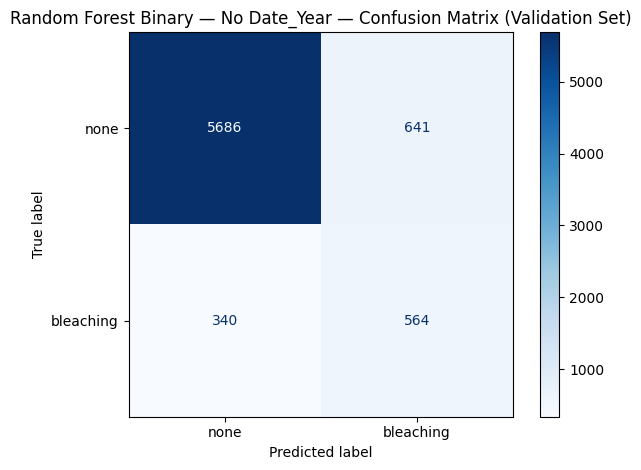

In [36]:
cm = confusion_matrix(y_val_bin, y_pred_no_year, labels=['none', 'bleaching'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['none', 'bleaching'])

disp.plot(cmap='Blues')
plt.title('Random Forest Binary — No Date_Year — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

### 6.2.1 Date_Year Ablation Results

Removing `Date_Year` from the feature set produces no meaningful change in performance:
- Bleaching recall: 0.61 → 0.62 (within noise)
- Macro F1: 0.73 → 0.73 (unchanged)
- False negatives: 349 → 340 (marginal improvement)

**Conclusion:** `Date_Year` does not introduce measurable temporal overfitting 
in this model. The thermal variables (SSTA, TSA_DHW, etc.) carry the predictive 
signal, not the year itself. `Date_Year` is retained in the final model.